In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("cement_dataset_cleaned_category_fineness_fullyear.csv")


df["Timestamp"] = pd.to_datetime(df["Timestamp"])
df = df.sort_values("Timestamp").reset_index(drop=True)

print(df.shape)
print(df.columns.tolist())

(7574, 42)
['Timestamp', 'WEIGHFEEDER_FlyAshTPH', 'GypsumTPH', 'ClinkerTPH', 'TOTALTPH', 'LOADKW_MOTOR1', 'MOTOR2', 'CMILPRmmWG', 'CMILTEMP°C', 'CMOLPRmmWG', 'CMOLMATTEMP°C', 'CMOLGASTEMP°C', 'CMOLBEAMP', 'CMOLBERPM', 'MILLSOUNDPercent', 'REJECTTPH', 'CMSEPDRIVESpeedRPM', 'CMSEPAMPS', 'CLNKHOPLVLM', 'FLYHOPLVLM', 'GYPHOPLVLM', 'PPCSILOLVLM', 'OPCSILOLVLM', 'CYC1DRAFTmmWG', 'CYC2DRAFTmmWG', 'CYC3DRAFTmmWG', 'CYC4DRAFTmmWG', 'SEPFANDAMPERPercent', 'SILOFEEDBEAMP', 'SEPFANAMP', 'SourceFile', 'YESTERDAYTOTALFEEDCUT', 'BC4TEMP°C', 'MAINBAGHOUSE_FANRPM', 'FANAMP', 'DP', 'AIRPRS', 'SEPFANKW', 'cement_type', 'flyash_ratio', 'cement_category', 'Fineness']


# Take needed columns only for first 2 relations

In [2]:
cols = [
    "Timestamp",
    "TOTALTPH",
    "CMOLBEAMP",
    "MILLSOUNDPercent",
    "cement_category"
]
data = df[cols].copy()
data.isnull().sum()

Timestamp           0
TOTALTPH            0
CMOLBEAMP           0
MILLSOUNDPercent    0
cement_category     0
dtype: int64

In [3]:
data.describe()

,Timestamp,TOTALTPH,CMOLBEAMP,MILLSOUNDPercent,cement_category
count,7574,7574.000000,7574.000000,7574.000000,7574.000000
mean,2025-07-15 05:33:23.908107008,115.854831,53.413121,79.867026,0.271191
min,2025-01-01 00:00:00,60.864471,40.586082,41.172161,0.000000
25%,2025-03-29 01:15:00,109.915693,47.912086,74.896217,0.000000
50%,2025-07-09 01:30:00,116.562025,50.940174,79.682541,0.000000
75%,2025-11-09 11:45:00,123.019908,57.582420,84.786324,1.000000
max,2026-01-30 23:00:00,151.288400,83.076927,96.923080,1.000000
std,NaN,11.913128,7.336166,7.231554,0.444604


In [4]:
print(data["cement_category"].value_counts())

cement_category
0.0    5520
1.0    2054
Name: count, dtype: int64


# Separate category 0 and 1

In [5]:
cat0 = data[data["cement_category"] == 0].copy()
cat1 = data[data["cement_category"] == 1].copy()

# First relation — TOTALTPH vs MILLSOUNDPercent

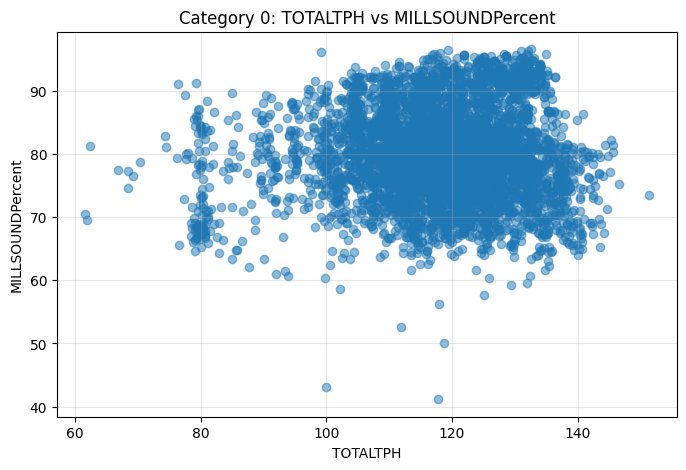

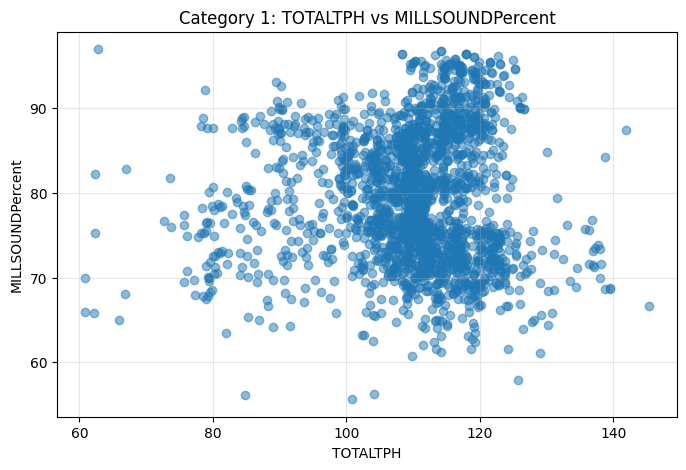

In [6]:
def plot_scatter(df_cat, xcol, ycol, title):
    plt.figure(figsize=(8,5))
    plt.scatter(df_cat[xcol], df_cat[ycol], alpha=0.5)
    plt.xlabel(xcol)
    plt.ylabel(ycol)
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.show()

plot_scatter(cat0, "TOTALTPH", "MILLSOUNDPercent", "Category 0: TOTALTPH vs MILLSOUNDPercent")
plot_scatter(cat1, "TOTALTPH", "MILLSOUNDPercent", "Category 1: TOTALTPH vs MILLSOUNDPercent")

# Create feed bins

In [7]:
def make_feed_bins(df_cat, tph_col="TOTALTPH", bin_width=2):
    df_cat = df_cat.copy()
    min_tph = np.floor(df_cat[tph_col].min())
    max_tph = np.ceil(df_cat[tph_col].max())
    bins = np.arange(min_tph, max_tph + bin_width, bin_width)
    df_cat["feed_bin"] = pd.cut(df_cat[tph_col], bins=bins, include_lowest=True)
    return df_cat

cat0_b = make_feed_bins(cat0, bin_width=2)
cat1_b = make_feed_bins(cat1, bin_width=2)

# Calculate operating envelope
For each feed bin, calculate:

median sound

std sound

25th percentile

75th percentile

count

In [8]:
def envelope_by_bin(df_cat, ycol, bin_col="feed_bin"):
    env = df_cat.groupby(bin_col)[ycol].agg(
        median="median",
        mean="mean",
        std="std",
        q25=lambda x: x.quantile(0.25),
        q75=lambda x: x.quantile(0.75),
        count="count"
    ).reset_index()
    return env

env_sound_cat0 = envelope_by_bin(cat0_b, "MILLSOUNDPercent")
env_sound_cat1 = envelope_by_bin(cat1_b, "MILLSOUNDPercent")

env_sound_cat0

C:\Users\Arin\AppData\Local\Temp\ipykernel_22708\1944875967.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  env = df_cat.groupby(bin_col)[ycol].agg(
C:\Users\Arin\AppData\Local\Temp\ipykernel_22708\1944875967.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  env = df_cat.groupby(bin_col)[ycol].agg(


,feed_bin,median,mean,std,q25,q75,count
0,"(60.999, 63.0]",70.476189,73.772893,6.574160,69.987789,75.909645,3
1,"(63.0, 65.0]",NaN,NaN,NaN,NaN,NaN,0
2,"(65.0, 67.0]",77.484741,77.484741,NaN,77.484741,77.484741,1
3,"(67.0, 69.0]",75.970695,75.970695,1.899432,75.299145,76.642246,2
4,"(69.0, 71.0]",77.667889,77.667889,1.605885,77.100122,78.235655,2
5,"(71.0, 73.0]",NaN,NaN,NaN,NaN,NaN,0
6,"(73.0, 75.0]",81.978024,81.978024,1.208731,81.550673,82.405375,2
7,"(75.0, 77.0]",79.413918,78.689458,12.750488,72.503052,85.238094,3
8,"(77.0, 79.0]",76.056168,75.700042,7.606973,68.870575,80.042736,12
9,"(79.0, 81.0]",71.037849,74.129829,7.242479,68.107452,80.537239,73


# Remove weak bins with too few points:

In [9]:
env_sound_cat0 = env_sound_cat0[env_sound_cat0["count"] >= 5].copy()
env_sound_cat1 = env_sound_cat1[env_sound_cat1["count"] >= 5].copy()

# Plot the operating envelope

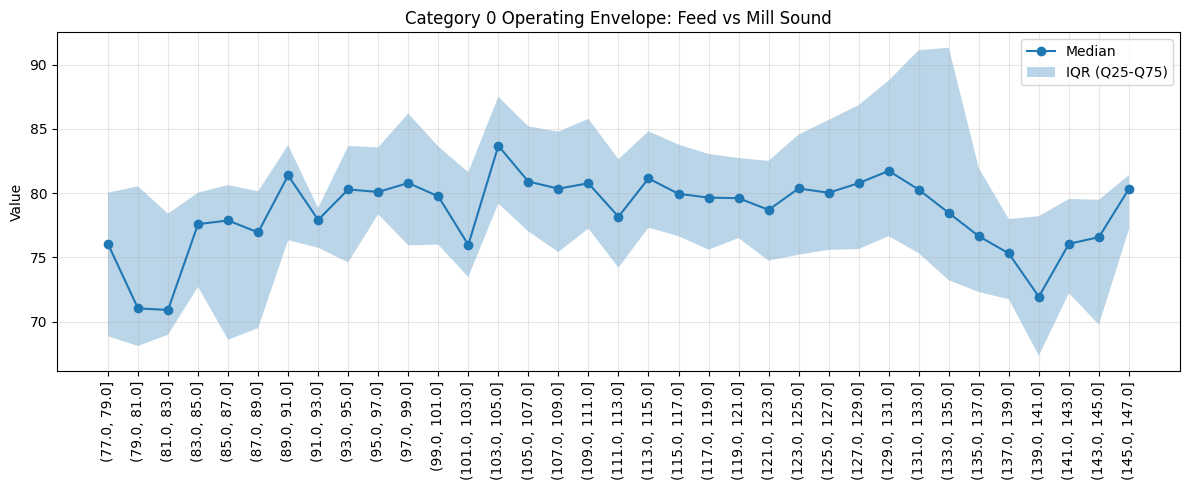

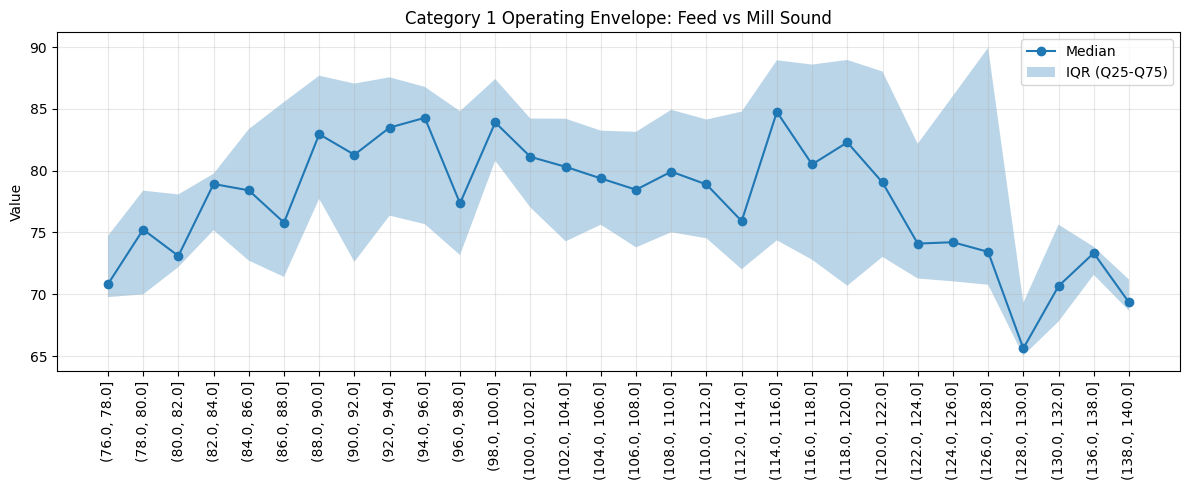

In [10]:
def plot_envelope(env, title):
    x = np.arange(len(env))
    labels = env["feed_bin"].astype(str)

    plt.figure(figsize=(12,5))
    plt.plot(x, env["median"], marker="o", label="Median")
    plt.fill_between(x, env["q25"], env["q75"], alpha=0.3, label="IQR (Q25-Q75)")
    plt.xticks(x, labels, rotation=90)
    plt.ylabel("Value")
    plt.title(title)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_envelope(env_sound_cat0, "Category 0 Operating Envelope: Feed vs Mill Sound")
plot_envelope(env_sound_cat1, "Category 1 Operating Envelope: Feed vs Mill Sound")

# Convert envelope into rules

Now for each incoming point, compare actual sound with the expected sound band for that feed bin.

Rule idea

For a given TOTALTPH bin:

if MILLSOUNDPercent > q75 → likely underloaded

if MILLSOUNDPercent < q25 → likely overloaded

else → stable

You can tighten or loosen later.

Create lookup table:

In [11]:
sound_lookup_cat0 = env_sound_cat0.set_index("feed_bin")[["median", "q25", "q75"]]
sound_lookup_cat1 = env_sound_cat1.set_index("feed_bin")[["median", "q25", "q75"]]

In [12]:
def classify_sound(feed_bin, actual_sound, lookup):
    if feed_bin not in lookup.index:
        return "unknown"

    low = lookup.loc[feed_bin, "q25"]
    high = lookup.loc[feed_bin, "q75"]

    if actual_sound < low:
        return "overloaded"
    elif actual_sound > high:
        return "underloaded"
    else:
        return "stable"

In [13]:
cat0_b["sound_status"] = cat0_b.apply(
    lambda row: classify_sound(row["feed_bin"], row["MILLSOUNDPercent"], sound_lookup_cat0),
    axis=1
)

cat0_b[["Timestamp", "TOTALTPH", "MILLSOUNDPercent", "feed_bin", "sound_status"]].head()


,Timestamp,TOTALTPH,MILLSOUNDPercent,feed_bin,sound_status
0,2025-01-01 00:00:00,121.751163,73.015877,"(121.0, 123.0]",overloaded
1,2025-01-01 01:00:00,119.021003,76.019539,"(119.0, 121.0]",overloaded
2,2025-01-01 02:00:00,122.926258,70.622711,"(121.0, 123.0]",overloaded
3,2025-01-01 03:00:00,121.687425,71.941391,"(121.0, 123.0]",overloaded
4,2025-01-01 04:00:00,122.418812,70.451775,"(121.0, 123.0]",overloaded


In [14]:

cat1_b["sound_status"] = cat1_b.apply(
    lambda row: classify_sound(row["feed_bin"], row["MILLSOUNDPercent"], sound_lookup_cat1),
    axis=1
)

cat1_b[["Timestamp", "TOTALTPH", "MILLSOUNDPercent", "feed_bin", "sound_status"]]

,Timestamp,TOTALTPH,MILLSOUNDPercent,feed_bin,sound_status
21,2025-01-01 21:00:00,91.679859,74.285713,"(90.0, 92.0]",stable
37,2025-01-02 13:00:00,97.543351,67.545792,"(96.0, 98.0]",overloaded
44,2025-01-02 20:00:00,122.287914,72.258850,"(122.0, 124.0]",stable
45,2025-01-02 21:00:00,121.526989,74.310135,"(120.0, 122.0]",stable
46,2025-01-02 22:00:00,123.579004,70.305252,"(122.0, 124.0]",overloaded
...,...,...,...,...,...
7471,2026-01-27 23:00:00,116.188033,81.098900,"(116.0, 118.0]",stable
7566,2026-01-30 16:00:00,99.494508,80.463982,"(98.0, 100.0]",overloaded
7567,2026-01-30 17:00:00,102.671549,86.153847,"(102.0, 104.0]",underloaded
7568,2026-01-30 18:00:00,108.732602,90.695969,"(108.0, 110.0]",underloaded


In [15]:
cat0_b["sound_status"].value_counts()


sound_status
stable         2763
underloaded    1372
overloaded     1371
unknown          14
Name: count, dtype: int64

In [16]:
cat1_b["sound_status"].value_counts()

sound_status
stable         1012
overloaded      510
underloaded     509
unknown          23
Name: count, dtype: int64

# So we must compute how far the system is from the stable band and convert that into a feed adjustment.

Concept: Reverse the relationship

Your envelope tells:
Feed → Expected Sound Range

But recommendation requires:
Sound deviation → Feed correction

So we calculate feed sensitivity to sound.

# Step 1: Estimate slope of the relation

In [17]:
import numpy as np

def fit_sound_feed_relation(df_cat):
    x = df_cat["TOTALTPH"].values
    y = df_cat["MILLSOUNDPercent"].values

    slope, intercept = np.polyfit(x, y, 1)

    return slope, intercept

m0, c0 = fit_sound_feed_relation(cat0)
m1, c1 = fit_sound_feed_relation(cat1)

print("Cat0 slope:", m0)
print("Cat1 slope:", m1)

Cat0 slope: 0.02565835187061236
Cat1 slope: 0.017434905151912893


# The slope may be statistically correct, but it is not suitable for recommendation magnitude. So we cant use slope logic

# Practical logic

For each row:

1. identify current feed bin

2. get current bin’s target sound (median)

3. compare actual sound vs target sound

4. search nearby bins for the feed whose median sound is closest to actual desired stable value

5. recommend a small bounded move, not a huge one

Even simpler operator-friendly version
Use stepwise recommendation bands, not exact formula.

Example:

    For sound relation

1. If point is outside the stable band:

2. mildly outside band → change feed by 1 TPH

3. moderately outside band → change feed by 2 TPH

4. severely outside band → change feed by 3 TPH

This is much better for operations.

# Lets use distance from envelope
deviation = actual_sound - median_sound_of_bin
band_width = q75 - q25
severity = deviation / band_width

Then map severity to feed move.

Example:
1. if stable:
    0 TPH
2. elif abs(severity) < 0.5:
    1 TPH
3. elif abs(severity) < 1.0:
    2 TPH
4. else:
    3 TPH

Then direction:

1. if sound_status == underloaded → increase feed

2. if sound_status == overloaded → reduce feed

3. if stable → maintain

## Important sign logic from our classification

From our current logic:

1. actual sound < q25 → overloaded

2. actual sound > q75 → underloaded

So recommendation should be:

1. overloaded → reduce feed

2. underloaded → increase feed

In [18]:
sound_lookup_cat0

,median,q25,q75
feed_bin,,,
"(77.0, 79.0]",76.056168,68.870575,80.042736
"(79.0, 81.0]",71.037849,68.107452,80.537239
"(81.0, 83.0]",70.915756,68.986572,78.412697
"(83.0, 85.0]",77.594631,72.716726,80.042736
"(85.0, 87.0]",77.875458,68.595852,80.634922
"(87.0, 89.0]",76.947495,69.499390,80.146523
"(89.0, 91.0]",81.379734,76.343105,83.742369
"(91.0, 93.0]",77.924301,75.750916,78.852257
"(93.0, 95.0]",80.293045,74.615387,83.675217


# Step 1: add target and band width

In [19]:
def add_sound_targets(df_cat, lookup):
    df_cat = df_cat.copy()

    df_cat["sound_median"] = df_cat["feed_bin"].apply(
        lambda x: lookup.loc[x, "median"] if x in lookup.index else np.nan
    )
    df_cat["sound_q25"] = df_cat["feed_bin"].apply(
        lambda x: lookup.loc[x, "q25"] if x in lookup.index else np.nan
    )
    df_cat["sound_q75"] = df_cat["feed_bin"].apply(
        lambda x: lookup.loc[x, "q75"] if x in lookup.index else np.nan
    )

    df_cat["sound_bandwidth"] = df_cat["sound_q75"] - df_cat["sound_q25"]
    df_cat["sound_deviation"] = df_cat["MILLSOUNDPercent"] - df_cat["sound_median"]

    return df_cat

cat0_b = add_sound_targets(cat0_b, sound_lookup_cat0)
cat1_b = add_sound_targets(cat1_b, sound_lookup_cat1)

# Step 2: compute severity

In [20]:
def safe_severity(row):
    bw = row["sound_bandwidth"]
    if pd.isna(bw) or bw == 0:
        return np.nan
    return row["sound_deviation"] / bw

cat0_b["sound_severity"] = cat0_b.apply(safe_severity, axis=1)
cat1_b["sound_severity"] = cat1_b.apply(safe_severity, axis=1)

# Step 3: map severity to feed recommendation

In [21]:
def feed_reco_from_sound(row, max_step=3):
    status = row["sound_status"]
    sev = abs(row["sound_severity"]) if pd.notna(row["sound_severity"]) else 0

    if status == "stable":
        return 0.0

    if sev < 0.5:
        step = 1.0
    elif sev < 1.0:
        step = 2.0
    else:
        step = 3.0

    step = min(step, max_step)

    if status == "underloaded":
        return step      # increase feed
    elif status == "overloaded":
        return -step     # reduce feed
    else:
        return 0.0

In [22]:
cat0_b["feed_recommendation_tph"] = cat0_b.apply(feed_reco_from_sound, axis=1)
cat1_b["feed_recommendation_tph"] = cat1_b.apply(feed_reco_from_sound, axis=1)

# Step 4: readable text

In [23]:
def reco_text(val):
    if val > 0:
        return f"Increase feed by {val:.1f} TPH"
    elif val < 0:
        return f"Reduce feed by {abs(val):.1f} TPH"
    else:
        return "Maintain current feed"
    
cat0_b["recommendation"] = cat0_b["feed_recommendation_tph"].apply(reco_text)
cat1_b["recommendation"] = cat1_b["feed_recommendation_tph"].apply(reco_text)

In [24]:
cat0_b

,Timestamp,TOTALTPH,CMOLBEAMP,MILLSOUNDPercent,cement_category,feed_bin,sound_status,sound_median,sound_q25,sound_q75,sound_bandwidth,sound_deviation,sound_severity,feed_recommendation_tph,recommendation
0,2025-01-01 00:00:00,121.751163,53.626377,73.015877,0.0,"(121.0, 123.0]",overloaded,78.705742,74.749695,82.515266,7.765572,-5.689865,-0.732704,-2.0,Reduce feed by 2.0 TPH
1,2025-01-01 01:00:00,119.021003,54.993896,76.019539,0.0,"(119.0, 121.0]",overloaded,79.609283,76.507935,82.735046,6.227112,-3.589745,-0.576470,-2.0,Reduce feed by 2.0 TPH
2,2025-01-01 02:00:00,122.926258,57.582420,70.622711,0.0,"(121.0, 123.0]",overloaded,78.705742,74.749695,82.515266,7.765572,-8.083031,-1.040880,-3.0,Reduce feed by 3.0 TPH
3,2025-01-01 03:00:00,121.687425,53.040295,71.941391,0.0,"(121.0, 123.0]",overloaded,78.705742,74.749695,82.515266,7.765572,-6.764351,-0.871069,-2.0,Reduce feed by 2.0 TPH
4,2025-01-01 04:00:00,122.418812,57.533581,70.451775,0.0,"(121.0, 123.0]",overloaded,78.705742,74.749695,82.515266,7.765572,-8.253967,-1.062892,-3.0,Reduce feed by 3.0 TPH
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7565,2026-01-30 15:00:00,107.122108,59.780224,89.108673,0.0,"(107.0, 109.0]",underloaded,80.354092,75.415142,84.786324,9.371181,8.754581,0.934203,2.0,Increase feed by 2.0 TPH
7570,2026-01-30 20:00:00,99.130651,66.178268,90.305252,0.0,"(99.0, 101.0]",underloaded,79.755798,75.995117,83.638588,7.643471,10.549454,1.380192,3.0,Increase feed by 3.0 TPH
7571,2026-01-30 21:00:00,104.230777,52.356537,89.719170,0.0,"(103.0, 105.0]",underloaded,83.687428,79.194138,87.509159,8.315022,6.031742,0.725403,2.0,Increase feed by 2.0 TPH
7572,2026-01-30 22:00:00,104.261301,55.286938,84.737488,0.0,"(103.0, 105.0]",stable,83.687428,79.194138,87.509159,8.315022,1.050060,0.126285,0.0,Maintain current feed


# Calculate how often the system recommends changes.

In [35]:
cat0_b["recommendation"].value_counts()

recommendation
Maintain current feed       2777
Reduce feed by 2.0 TPH       735
Increase feed by 2.0 TPH     710
Increase feed by 3.0 TPH     625
Reduce feed by 3.0 TPH       506
Reduce feed by 1.0 TPH       130
Increase feed by 1.0 TPH      37
Name: count, dtype: int64

# What you have successfully built so far

You now have a complete rule framework for Relation 1:

Inputs

1.    TOTALTPH

2.    MILLSOUNDPercent

3.    cement_category

Model

sound Operating envelope per feed bin:

1. median 

2. Q25

3. Q75

## !!! The stable operating envelope is learned from historical data using median and interquartile ranges. These thresholds can be adjusted by process experts if the plant’s preferred operating zone differs from historical behavior.